# **Analyzing the Sales and Profitability Drivers in a Superstore**

## **Index**

1) Goal of this Project
2) Dataset Overview
3) Data Cleaning
4) SQL Analysis - Business Driven Insights
5) EDA and Data Visualization
6) Key Insights and Business Recommendations 

## **1] Goal of this Project** 

Profit is the crux of a business's sustainability. For retail businesses, it is essential to ensure that products, regions and customer segments contribute positively to overall profitability. 

This project analyzes 9,994 orders from 2014 to 2017, with shipping activity extending into early 2018, from a large superstore to assess profitability and identify which products, regions, categories and customer segments to target or avoid. 

## **2] Dataset Overview**

Below are the details of the columns that this dataset contains - 

1) **Row ID** - Unique ID for each row (serial number) 
2) **Order ID** - Unique Order ID for each customer's purchase order 
3) **Order Date** - Date on which the product was ordered
4) **Ship Date** - Shipping Date of the product
5) **Ship Mode** - Mode of shipment of the product
6) **Customer ID** - Unique ID to identify each customer
7) **Customer Name** - Name of the customer
8) **Segment** - Customer segment (Consumer, Corporate, Home Office) 
9) **Country** - Country of residence of the customer
10) **City** - City of residence of the customer
11) **State** - State of residence of the customer
12) **Postal Code** - Postal Code of the customer
13) **Region** - Region from which the customer belongs
14) **Product ID** - Unique ID of the product
15) **Category** - Category under which the ordered product falls
16) **Sub-Category** - Sub-Category of the product ordered
17) **Product Name** - Name of the product
18) **Sales** - Sales value of the product
19) **Quantity** - Quantity of the product ordered 
20) **Discount** - Discount provided
21) **Profit** - Profit or Loss incurred

#### **Source of the Dataset -**
Kaggle Datasets - https://www.kaggle.com/datasets/vivek468/superstore-dataset-final

(**Note** - This dataset was originally found by the author in the Trailblazer Community of SalesForce - https://trailhead.salesforce.com/trailblazer-community/feed/0D5KX00000kQPXv0AO)

## **3] Data Cleaning**

In [1]:
# Importing all the required packages and libraries for data cleaning and EDA
import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt 
import seaborn as sns
import datetime 

In [2]:
# Importing the Superstore's dataset and standardizing the data types of some columns to prevent any errors and inconsistencies
df = pd.read_csv(r"C:\Users\Dell\OneDrive\Superstore Dataset.csv")

df['Order Date'] = pd.to_datetime(df['Order Date'], dayfirst=True)
df['Ship Date'] = pd.to_datetime(df['Ship Date'], dayfirst=True)

df['Row ID'] = df['Row ID'].astype(int)
df['Postal Code'] = df['Postal Code'].astype(str)
df['Sales'] = df['Sales'].astype(float)
df['Quantity'] = df['Quantity'].astype(int)
df['Discount'] = df['Discount'].astype(float)
df['Profit'] = df['Profit'].astype(float)

In [3]:
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,2016-06-12,2016-06-16,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


### **1) CHECKING FOR DATA TYPE INCONSISTENCIES & NULL VALUES**

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   Row ID         9994 non-null   int64         
 1   Order ID       9994 non-null   object        
 2   Order Date     9994 non-null   datetime64[ns]
 3   Ship Date      9994 non-null   datetime64[ns]
 4   Ship Mode      9994 non-null   object        
 5   Customer ID    9994 non-null   object        
 6   Customer Name  9994 non-null   object        
 7   Segment        9994 non-null   object        
 8   Country        9994 non-null   object        
 9   City           9994 non-null   object        
 10  State          9994 non-null   object        
 11  Postal Code    9994 non-null   object        
 12  Region         9994 non-null   object        
 13  Product ID     9994 non-null   object        
 14  Category       9994 non-null   object        
 15  Sub-Category   9994 n

- **Standardization of Order Date and Ship Date while importing the dataset to this notebook was performed to avoid any logistical inconsistencies.**
- **`parse_dates` parameter was initially used to automatically detect and convert the above columns to datetime, which silently failed.** 
- **Row ID and Quantity columns were standardized to int data type from float, while Postal Code was standardized to str data type to ensure semantic consistencies and avoid unnecessary floating-point representation.**
- **All the columns now align with the expected analytical usage and can be used for analysis, after the above treatments were performed.**

In [5]:
# Checking for Null Values 
df.isnull().sum()

Row ID           0
Order ID         0
Order Date       0
Ship Date        0
Ship Mode        0
Customer ID      0
Customer Name    0
Segment          0
Country          0
City             0
State            0
Postal Code      0
Region           0
Product ID       0
Category         0
Sub-Category     0
Product Name     0
Sales            0
Quantity         0
Discount         0
Profit           0
dtype: int64

**`No NULL` rows or columns were observed in the dataset.**

### **2) CHECKING FOR DUPLICATES**

In [6]:
df.shape

(9994, 21)

In [7]:
# Checking for duplicates
df.drop_duplicates().shape

(9994, 21)

**From the above code results, it is evident that this dataset does `not contain any duplicate values`**

### **3) NEGATIVE VALUES CHECK**

In [8]:
# Checking for Negative Sales (which is usually invalid)
df[df['Sales']<0]

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit


**There were `NO Negative Sales` values observed (which would indicate invalid transactions).**

In [9]:
# Checking for negative profits (loss) 
df[df['Profit']<0]

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
3,4,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
14,15,US-2015-118983,2015-11-22,2015-11-26,Standard Class,HP-14815,Harold Pawlan,Home Office,United States,Fort Worth,...,76106,Central,OFF-AP-10002311,Office Supplies,Appliances,Holmes Replacement Filter for HEPA Air Cleaner...,68.8100,5,0.80,-123.8580
15,16,US-2015-118983,2015-11-22,2015-11-26,Standard Class,HP-14815,Harold Pawlan,Home Office,United States,Fort Worth,...,76106,Central,OFF-BI-10000756,Office Supplies,Binders,Storex DuraTech Recycled Plastic Frosted Binders,2.5440,3,0.80,-3.8160
23,24,US-2017-156909,2017-07-16,2017-07-18,Second Class,SF-20065,Sandra Flanagan,Consumer,United States,Philadelphia,...,19140,East,FUR-CH-10002774,Furniture,Chairs,"Global Deluxe Stacking Chair, Gray",71.3720,2,0.30,-1.0196
27,28,US-2015-150630,2015-09-17,2015-09-21,Standard Class,TB-21520,Tracy Blumstein,Consumer,United States,Philadelphia,...,19140,East,FUR-BO-10004834,Furniture,Bookcases,"Riverside Palais Royal Lawyers Bookcase, Royal...",3083.4300,7,0.50,-1665.0522
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9920,9921,CA-2016-149272,2016-03-15,2016-03-19,Standard Class,MY-18295,Muhammed Yedwab,Corporate,United States,Bryan,...,77803,Central,OFF-BI-10004233,Office Supplies,Binders,"GBC Pre-Punched Binding Paper, Plastic, White,...",22.3860,7,0.80,-35.8176
9921,9922,CA-2014-111360,2014-11-24,2014-11-30,Standard Class,AT-10435,Alyssa Tate,Home Office,United States,Akron,...,44312,East,OFF-BI-10003350,Office Supplies,Binders,Acco Expandable Hanging Binders,5.7420,3,0.70,-4.5936
9931,9932,CA-2015-104948,2015-11-13,2015-11-17,Standard Class,KH-16510,Keith Herrera,Consumer,United States,San Bernardino,...,92404,West,FUR-BO-10004357,Furniture,Bookcases,O'Sullivan Living Dimensions 3-Shelf Bookcases,683.3320,4,0.15,-40.1960
9937,9938,CA-2016-164889,2016-06-03,2016-06-06,Second Class,CP-12340,Christine Phan,Corporate,United States,Los Angeles,...,90049,West,FUR-TA-10001676,Furniture,Tables,Hon 61000 Series Interactive Training Tables,71.0880,2,0.20,-1.7772


**Out of 9994 orders, `1871 orders made negative profits`. This means that 18.7212% ~ `19%` of the orders made negative profits and represent legitimate loss-making orders.**

In [10]:
# Checking for negative quantities 
df[df['Quantity']<0]

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit


**There were `no negative quantities found` which means that all the data is valid.**

In [11]:
# Checking for 0 quantity 
df[df['Quantity']==0]

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit


In [12]:
df['Quantity'].min()

np.int64(1)

**This implies that all the orders have atleast `1 product and above`. If no products were being shipped in any of the orders, this could have been flagged as suspicious activity, which is not the case with this dataset.**

### **4) DISCOUNT RANGE CHECK**

In [13]:
df['Discount'].describe()

count    9994.000000
mean        0.156203
std         0.206452
min         0.000000
25%         0.000000
50%         0.200000
75%         0.200000
max         0.800000
Name: Discount, dtype: float64

**From the above code output, it is clear that the `discount values range between 0 and 0.80`, indicating discounts are represented as proportions (0-80%). NO invalid values (such as negative discounts or values exceeding 1) were observed.**

### **5) LOGISTICAL INCONSISTENCIES CHECK**

During data cleaning, it was observed that the years in which **`orders were placed spanned between 2014 and 2017`** while the **`years in which the products were shipped extended into 2018`** as well. This section of the data cleaning process was conducted to ensure that there were no logistical inconsistencies or suspicious logistical activities detected in this dataset. The data types for Order Date and Ship Date were converted to the Datetime data type while importing the dataset, before checking for logistical inconsistencies.   

In [14]:
(df['Order Date'] > df['Ship Date']).sum()

np.int64(0)

**There were NO Ship Dates prior to Order Dates in this dataset and this means there were NO invlaid data points found.**

### **6) INCONSISTENCIES CHECK FOR SEGMENT, REGION, CATEGORIES & SUB-CATEGORIES COLUMNS**

This section of the data cleaning process aims to double-check for any inconsistencies in the categories for the following columns - 
1) Segment
2) Region
3) Category
4) Sub-Category

In [15]:
df['Segment'].unique()

array(['Consumer', 'Corporate', 'Home Office'], dtype=object)

In [16]:
df['Region'].unique()

array(['South', 'West', 'Central', 'East'], dtype=object)

In [17]:
df['Category'].unique()

array(['Furniture', 'Office Supplies', 'Technology'], dtype=object)

In [18]:
df['Sub-Category'].unique()

array(['Bookcases', 'Chairs', 'Labels', 'Tables', 'Storage',
       'Furnishings', 'Art', 'Phones', 'Binders', 'Appliances', 'Paper',
       'Accessories', 'Envelopes', 'Fasteners', 'Supplies', 'Machines',
       'Copiers'], dtype=object)

**There were `NO duplicate categories found` under each of the above columns.**

### **7) OUTLIERS CHECK** 

This section aims to detect and explain any extreme values. 

In [19]:
df[['Sales', 'Profit', 'Quantity']].describe()

,Sales,Profit,Quantity
count,9994.000000,9994.000000,9994.000000
mean,229.858001,28.656896,3.789574
std,623.245101,234.260108,2.225110
min,0.444000,-6599.978000,1.000000
25%,17.280000,1.728750,2.000000
50%,54.490000,8.666500,3.000000
75%,209.940000,29.364000,5.000000
max,22638.480000,8399.976000,14.000000


**Although Sales and Profit exhibit high variance and skewness, these reflect real-world business scenarios such as bulk-purchases and high-value transactions. Hence, `NO outlier treatment was applied` to preserve business relevance.**

**Interpretation -**

From the above data cleaning that was performed, the following can be noted - 
1) Initial inspection showed inconsistencies in Order Date, Ship Date, Row ID, Postal Code and Quantity, which were corrected while importing the dataset to ensure analytical consistency. 
2) No Null rows or columns found
3) No duplicates found.
4) No negative sales, negative quantities or 0 quantities found, which means that `No anomalies indicative of operational or data integrity issues were observed`.
5) `1871 loss-making orders` identified, which is valid.
6) No invalid date relationships found as the data type was changed to Datetime from Object Data type.
7) No duplicate or inconsistent data categories found. 

Hence, this **`dataset is now clean and ready for analysis`**. 

## **4] SQL Analysis - Business Driven Insights**

After performing data cleaning to ensure the data is clean and usable for data analysis, SQL (Structured Query Language) Analysis is used to gain meaningful business-driven insights from the dataset. The analysis focuses on understanding sales performance, profitability and key drivers across regions, customer segments and categories. 

In [20]:
%load_ext sql

# Importing the library to work with SQL in Jupyter Notebook
import sqlite3

# Creating a temporary database in RAM
conn = sqlite3.connect("Superstore.db")

# Loading the dataframe into SQL
df.to_sql("Superstore", conn, if_exists="replace", index=False)

# Connecting Jupyter Notebook to SQLite database
%sql sqlite:///Superstore.db

In [21]:
# Downgraded prettytable to version 3.9.0 (previously upgraded version was 3.17.0) because the new version does not support the DEFAULT style
!pip uninstall prettytable -y
!pip install prettytable==3.9.0

Found existing installation: prettytable 3.9.0
Uninstalling prettytable-3.9.0:
  Successfully uninstalled prettytable-3.9.0
  Using cached prettytable-3.9.0-py3-none-any.whl.metadata (26 kB)
Using cached prettytable-3.9.0-py3-none-any.whl (27 kB)


In [22]:
# Return results as a pandas DataFrame and avoid formatting issues
%config SqlMagic.autopandas = True

In [23]:
%%sql 
SELECT * 
FROM Superstore 
LIMIT 5;

 * sqlite:///Superstore.db
Done.


,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,2016-11-08 00:00:00,2016-11-11 00:00:00,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,2016-11-08 00:00:00,2016-11-11 00:00:00,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,2016-06-12 00:00:00,2016-06-16 00:00:00,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,2015-10-11 00:00:00,2015-10-18 00:00:00,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,2015-10-11 00:00:00,2015-10-18 00:00:00,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


### **1) What are the total Sales, Profit and Number of Orders by Region?**

In [24]:
%%sql
SELECT 
       Region, 
       COUNT(DISTINCT "Order ID") AS Total_Orders, 
       ROUND(SUM(Sales), 2) AS Total_Sales,
       ROUND(SUM(Profit), 2) AS Total_Profit
FROM Superstore
GROUP BY Region
ORDER BY Total_Sales DESC;

 * sqlite:///Superstore.db
Done.


,Region,Total_Orders,Total_Sales,Total_Profit
0,West,1611,725457.82,108418.45
1,East,1401,678781.24,91522.78
2,Central,1175,501239.89,39706.36
3,South,822,391721.91,46749.43


**Business Insights -**

According to the results of the above code, the West region generates the highest sales value **`(~725K)`**, followed by the East region, which denotes better market performance in the two regions. However, additional study is needed to determine whether increased sales lead to the same increase in profit. 

In contrast, the Central region has a much lower profit **`(~40K)`**, whereas the sales in the Central region are moderate **`(~501K)`**. This indicates a potential over-dependence on discounting strategies or a high operational cost. The Southern region displays similar patterns. 

**`Both Central and Southern regions together account for about 20% of total orders while earning a much lower profit`**, which could be a sign of potential pricing or discounting inefficiencies. This is consistent with loss-making orders found during the data cleaning stage of this project. 

### **2) What are the total Sales, Profit and Number of Orders by Customer Segment?**

In [25]:
%%sql
SELECT 
      Segment,
      COUNT(DISTINCT "Order ID") AS Total_Orders,
      ROUND(SUM(Sales), 2) AS Total_Sales,
      ROUND(SUM(Profit), 2) AS Total_Profits
FROM Superstore
GROUP BY Segment
ORDER BY Total_Sales DESC;

 * sqlite:///Superstore.db
Done.


,Segment,Total_Orders,Total_Sales,Total_Profits
0,Consumer,2586,1161401.34,134119.21
1,Corporate,1514,706146.37,91979.13
2,Home Office,909,429653.15,60298.68


**Business Insights -**

According to the results of the above code, the Consumer segment contributes the highest share of both total sales `(~1.16M)` and total profit `(~134K)`, indicating that the Consumer sector is the primary driver of revenue for this Superstore. 

The Corporate segment follows with moderate sales `(~706K)` and profit `(~91K)`, while Home Office segment generates the lowest sales `(~429K)` and profit `(~60K)`. 

**`Across all the customer segments, profits remain significantly lower than sales`**, which is expected in a retail business. However, the consumer segment demonstrates relatively stronger profitability in absolute terms, making it a key focus area for revenue generation strategies. 

While the Consumer segment leads in total contribution, further analysis is required to evaluate profit margins across segments to determine which segment is most efficient in generating profit relative to sales. 

### **3) What are the total Sales, Profit and Number of Orders by product Category?**

In [26]:
%%sql
SELECT 
      Category,
      COUNT(DISTINCT "Order ID") AS Total_Orders,
      ROUND(SUM(Sales), 2) AS Total_Sales,
      ROUND(SUM(Profit), 2) AS Total_Profits
FROM Superstore
GROUP BY Category 
ORDER BY Total_Profits DESC;  

 * sqlite:///Superstore.db
Done.


,Category,Total_Orders,Total_Sales,Total_Profits
0,Technology,1544,836154.03,145454.95
1,Office Supplies,3742,719047.03,122490.80
2,Furniture,1764,741999.80,18451.27


**Business Insights -**

From the output of the above code, the Technology category of products generates the highest share of both Sales `(~836K)` and Profit `(~145K)`, indicating that it is the most valuable product category in terms of both revenue and profitability. 

Office Supplies follows with strong sales `(~719K)` and profit `(~122K)`, suggesting consistent demand and stable performance. 

In contrast, the Furniture category records relatively high sales of `(~741K)` but significantly lower profit of `(~18K)`, indicating potential issues such as high discounting, increased costs or lower profit margins. 

**`Across all product categories, total profit remains significantly lower than sales`**. This is expected in retail operations. However substantial gap between sales and profit in the Furniture category highlights a potential area of concern. 

Further analysis of profit margins is required to evaluate category-level efficiency and identify opportunities for improving profitability.

### **4) Which Sub-Category of Products Perform well?** 

In [27]:
%%sql
SELECT *,
         RANK() OVER (ORDER BY Total_Profits DESC) AS Rank_by_Profit
FROM ( 
    SELECT
          "Sub-Category",
           COUNT(DISTINCT "Order ID") AS Total_Orders,
           ROUND(SUM(Sales), 2) AS Total_Sales,
           ROUND(SUM(Profit), 2) AS Total_Profits
    FROM Superstore
    GROUP BY "Sub-Category"
    );

 * sqlite:///Superstore.db
Done.


,Sub-Category,Total_Orders,Total_Sales,Total_Profits,Rank_by_Profit
0,Copiers,68,149528.03,55617.82,1
1,Phones,814,330007.05,44515.73,2
2,Accessories,718,167380.32,41936.64,3
3,Paper,1191,78479.21,34053.57,4
4,Binders,1316,203412.73,30221.76,5
5,Chairs,576,328449.10,26590.17,6
6,Storage,777,223843.61,21278.83,7
7,Appliances,451,107532.16,18138.01,8
8,Furnishings,877,91705.16,13059.14,9
9,Envelopes,249,16476.40,6964.18,10


**Business Insights -**

The above sub-category analysis shows a clear variation in profitability across products. Copiers rank highest in total profit `(~56K profit)` despite having a very low order volume, which suggests that they are high-margin products. Phones and Accessories follow next and contribute strongly to the overall profits, backed by relatively hgiher sales.

On the other hand, several sub-categories such as Tables `(~ -17K)`, Bookcases `(~ -3.4K)` and Supplies `(~ -1.1K)` rank at the bottom and generate consistent negative profits (losses) despite having decent sales. This indicates potential issues such as excessive discounting, high costs, or inefficient pricing strategies. 

Additionally, sub-categories like Binders and Paper generate a high number of orders, but do not rank as high in profitability, suggesting that higher sales do not always translate into higher profits. 

Overall, the ranking makes it evident that profitability is uneven across sub-categories, and focusing only on sales volume can be misleading. Certain products may require pricing or cost optimization to improve margins. 

**From the above four business questions, we were able to understand that -**

- **`West Region generates the highest sales and profitability` followed by `East Region`. Central and Southern regions account for 20% of the total orders while earning a profit lower than sales, hinting toward potential discounting and/or pricing inefficiencies.**
- **`Consumer Segment contributes the highest in terms of sales and profitability`, but across all the customer segments, profits are significantly lower than sales.**
- **`Technology is the most valuable category in terms of revenue and profitability`, but `Furniture has a substantial gap between sales and profit`, which proves that strong revenue does not guarantee higher profits. This highlights the real-world concern of management ownership problems where the goals of the management and owners conflict.**
- **`Copiers are the most profitable sub-category despite having the lowest order volume`, while Tables are the most loss-making sub-category, even though this product has a decent order volume.**

**The above insights hint at one thing - `figuring out if the business is profitable overall has become mandatory for this analysis`.**

### **5) How profitable is this Superstore?**

In [28]:
%%sql
SELECT 
      SUM(Sales) AS Total_Sales,
      SUM(Profit) AS Total_Profit,
      ROUND(SUM(Profit) * 100.0 / SUM(Sales), 2) AS Profit_Margin_Percentage
FROM Superstore;

 * sqlite:///Superstore.db
Done.


,Total_Sales,Total_Profit,Profit_Margin_Percentage
0,2.297201e+06,286397.0217,12.47


**Business Insights -**

This Superstore generates a total profit margin of 12.47%, indicating that the business is moderately profitable. This means that, for every unit of revenue generated, approximately 12% is retained as profit after costs. 

While this reflects a healthy level of profitability for a retail business, it is not particularly strong. For a retail business, a profit margin of more than 20% is considered strong, but this is not the case. `Previous analysis highlights that certain categories and sub-categories - such as Furniture and Tables are significantly underperforming and contributing to reduced overall margins`. 

Additionally, **`regional inefficiencies and potential over-discounting strategies may be further impacting profitability`**.  

The current profit margin suggests that the business is sustainable, but not optimized for maximum profitability. Hence, there is considerable scope for improvement by addressing loss-making products, optimizing pricing strategies, and focusing on high-margin segments. 

### **6) What is the Impact of Discount on Profit?**

This section of the SQL Analysis focuses on figuring out how discounting strategies are hampering profitability of the Superstore. 

In [29]:
%%sql
SELECT 
      Discount, 
      COUNT(*) AS Orders, 
      ROUND(AVG(Profit), 2) AS Average_Profit
FROM Superstore
GROUP BY Discount
ORDER BY Discount 

 * sqlite:///Superstore.db
Done.


,Discount,Orders,Average_Profit
0,0.00,4798,66.90
1,0.10,94,96.06
2,0.15,52,27.29
3,0.20,3657,24.70
4,0.30,227,-45.68
5,0.32,27,-88.56
6,0.40,206,-111.93
7,0.45,11,-226.65
8,0.50,66,-310.70
9,0.60,138,-43.08


**Business Insights -**

The pattern observed above is interestingly the same as the one thought to be the reason for negative profits - heavy discounting strategies. The reason has been explained. 

From the output of the above code, it is observed that, when the discount is 0%, the average profit is `(~67)`. The maximum discount that worked in favour of increasing profits was 10% discount. 

After that, a strong inverse relationship between discounts and profits is observed. **`As the discount increases beyond 20%, the average profit declines significantly`**. Products with a 30% discount or higher consistently result in negative profits, indicating severe erosion in profit margins. 

This suggests that aggressive discounting strategies are a key driver of losses within the business. While discounting may help increase the volume of sales, it adversely impacts the overall profitability of the business. 

Therefore, optimizing pricing strategies and limiting the discounts beyond 20% could help significantly improve profit margins and overall business performance. 

## **5] EDA and Data Visualization**

Fromn the above SQL Analysis, it was evident that there is a wide gap between revenue and profits especially with the Furniture category. The other main discovery was that heavy diascounting hampers profitability. In this section, we will understand this clearly along with clear visuals of customer segment and regional performance. 

### **1) Sales Vs. Profit by Category**

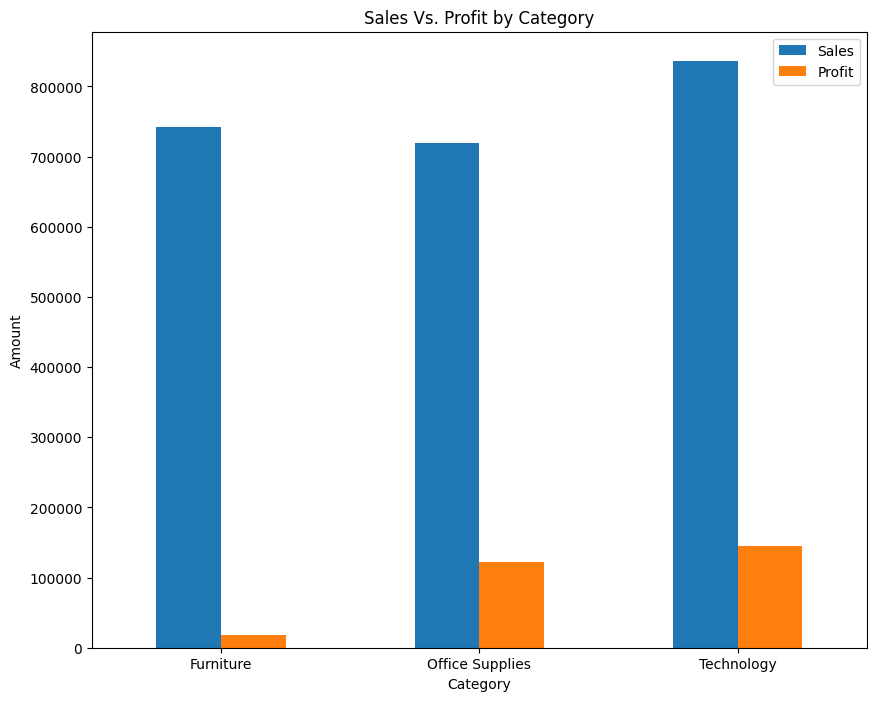

In [30]:
# Bar Chart depicitng the gap between sales and profits
Category_Summary = df.groupby("Category")[["Sales", "Profit"]].sum().reset_index()

Category_Summary.plot(x="Category",
                      kind="bar",
                      figsize=(10,8)
                     )
plt.title("Sales Vs. Profit by Category")
plt.ylabel("Amount")
plt.xticks(rotation=0)
plt.show()

**Business Insights -**

The above bar chart indicates that the Furniture category generates strong sales **`~741K`** but significantly poor profit margins **`~18K`**. Technology and Office Supplies generate a decent amount of revenue and profits, but all the categories generate profits lower than sales due to heavy discounting of furniture like tables, office supplies like bookcases and supplies, technology like machines and so on. 

### **2) Prpofit by Sub-Category** 

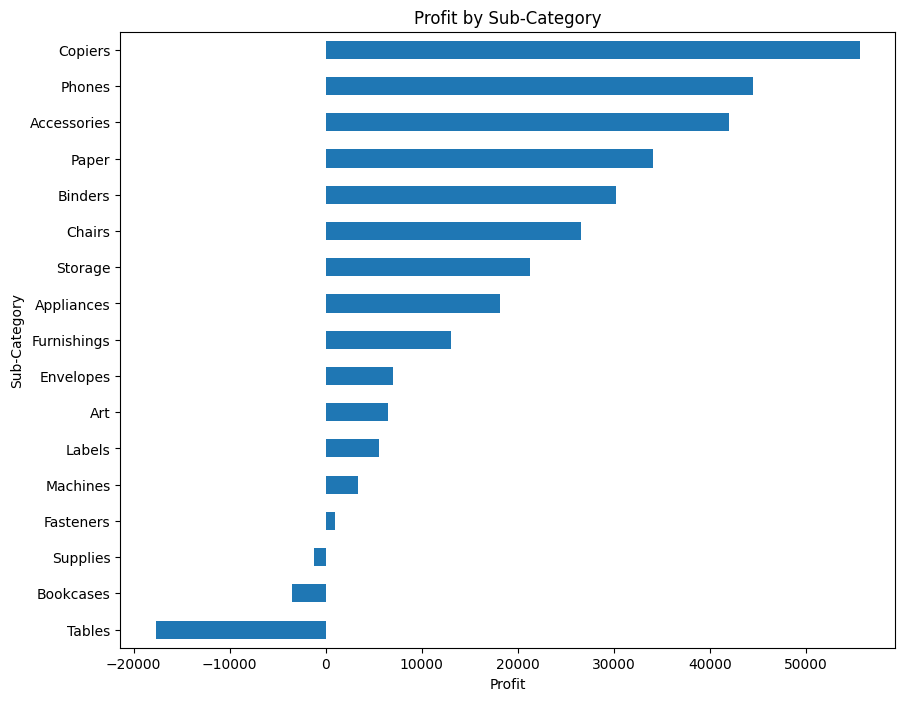

In [31]:
# Bar Chart depicting the profit of the Superstore by sub-category
SubCategory_Profit = df.groupby("Sub-Category")["Profit"].sum().sort_values()
plt.figure(figsize=(10,8))
SubCategory_Profit.plot(kind="barh")
plt.title("Profit by Sub-Category")
plt.xlabel("Profit")
plt.show()

**Business Insights -**

The loss making sub-categories are Tables, Bookcases and Supplies while the top 3 performers are Copiers, Phones and Accessories. 

### **3) Discount Vs. Profits Relationship**

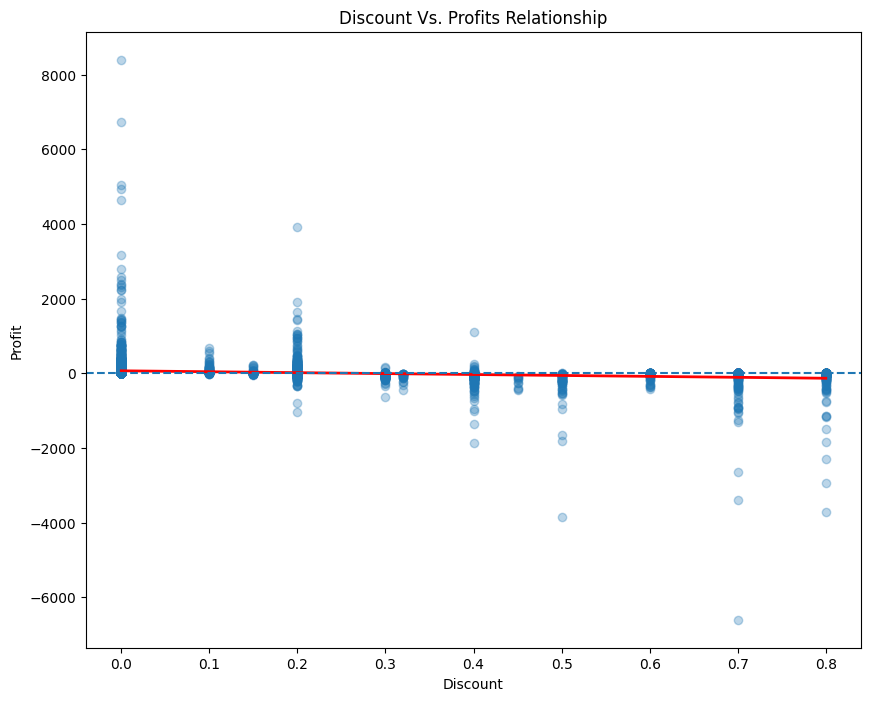

In [32]:
# A regression plot showing the relationship between discounts and profits 
plt.figure(figsize=(10,8))
sns.regplot(x='Discount', 
            y='Profit', 
            data=df, 
            scatter_kws={"alpha": 0.3},
            line_kws={"color": "red", "linewidth": 2})
plt.axhline(0, linestyle="--")
plt.title("Discount Vs. Profits Relationship")
plt.show()

**Business Insights -**

The above scatter plot suggests an evident inverse relationship between Discount and Profit. Transactions with discounts below **`~20%`** are generally profitable. However, as discounts increase more than 20%, profits decline sharply, as visible in the regression plot above, with higher discounts consistently resulting in huge losses. This indicates that aggressive discounting is the key driver of reduced profitability, suggesting the need for stricter discount controlling strategies. 

### **4) Regional Performance**

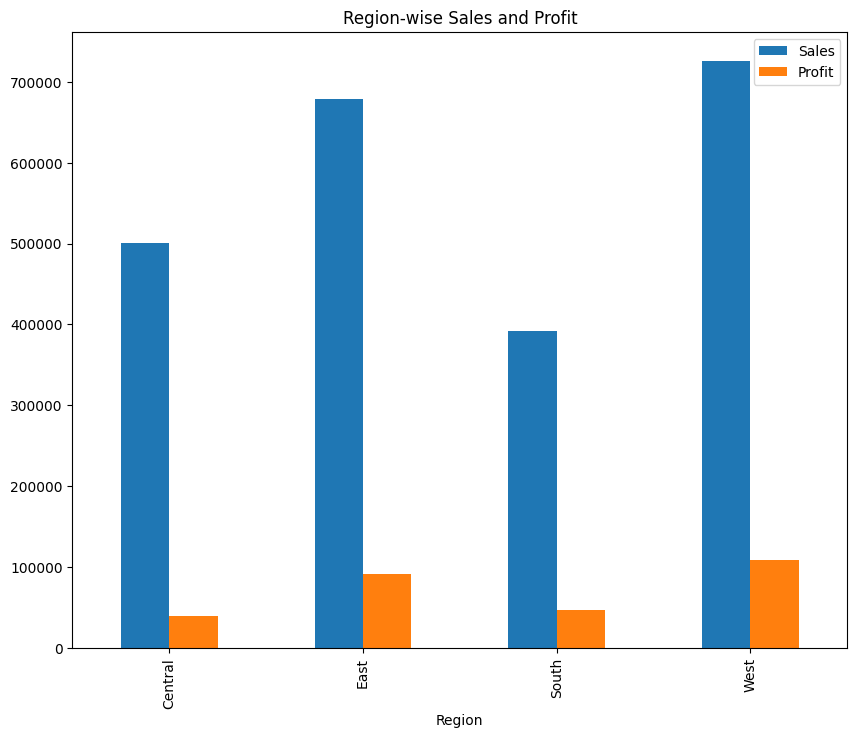

In [33]:
# Bar Chart depicitng regional performance of sales and profits
Regional_Summary = df.groupby("Region")[["Sales", "Profit"]].sum().reset_index()
Regional_Summary.plot(x="Region",
                      kind="bar",
                      figsize=(10,8))
plt.title("Region-wise Sales and Profit")
plt.show()

**Business Insights -**

The above bar chart indicates that the West followed by the East regions outperform the other regions while the Central region shows weaker profitability despite moderate sales. But the profits are consistently lower than the sales. 

### **5) Customer Segment Analysis**

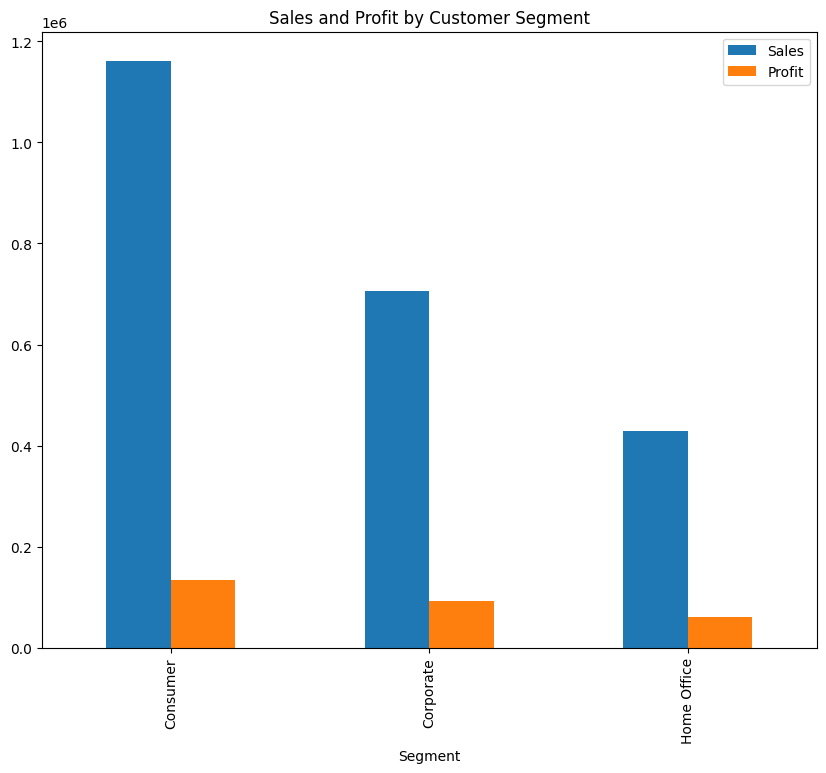

In [34]:
# Bar chart depicitng the Sales and Profit by Customer Segment 
Segment_Summary = df.groupby("Segment")[['Sales', 'Profit']].sum().reset_index()
Segment_Summary.plot(x="Segment",
                     kind="bar",
                     figsize=(10,8))
plt.title("Sales and Profit by Customer Segment")
plt.show()

**Business Insights -**

The Consumer segment drives the highest revenue **`(~1.16M)`** and profit **`(~134K)`**, making it the key driver of the Superstore's business.  

### **6) Profit Distribution**

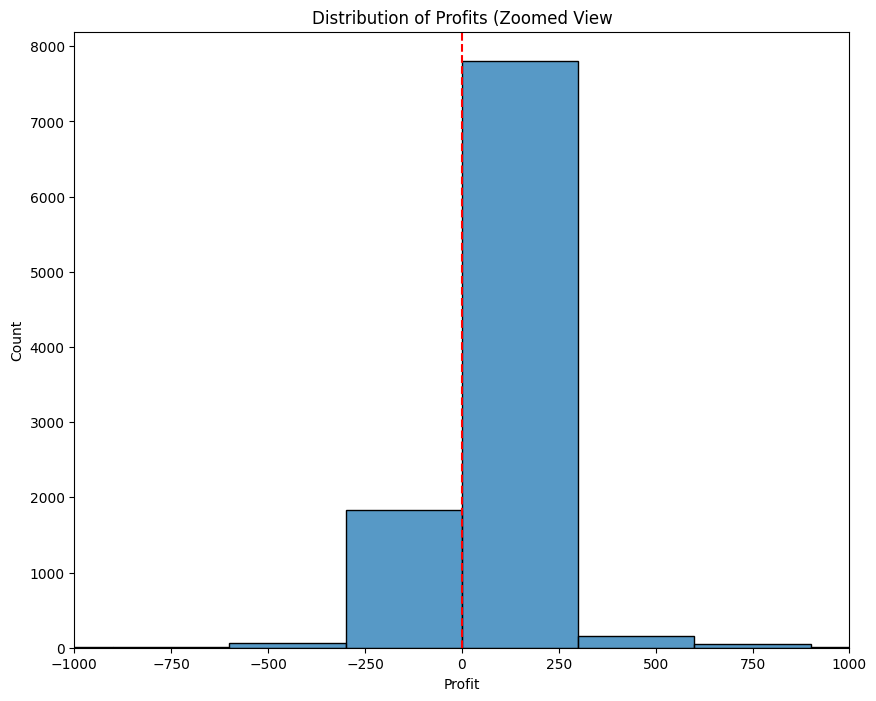

In [35]:
# A histogram showing the distribution of profits in this dataset 
plt.figure(figsize=(10,8))
sns.histplot(df["Profit"], bins=50)
plt.axvline(0, color="red", linestyle="--")
plt.xlim(-1000, 1000)
plt.title("Distribution of Profits (Zoomed View")
plt.show()

**Business Insights -**

The profit distribution indicates that, while many transactions are slightly profitable, with values concentrated just above 0, a substantial number result in losses, indicating an inconsistent profitability across orders. While loss-making transactions are present, they occur less frequently. However, the narrow spread around 0 suggests that a large portion of transactions cluster around low profit margins, indicating limited profitability per order. 

## **6] Key Insights and Business Recommendations**

### **1) Key Insights -**

1) The above data analysis suggests that higher discounts above **`~20%`** were associated with decreased profitability.  
2) The Furniture category generates high sales but disproportionately lower profit margins, indicating that the costs or discounting may be too high relative to the revenue.
3) Sub-Categories such as Tables and Bookcases are consistently loss-making.
4) Regional performance varies, with the Central region underperforming in profitability, despite moderate sales. 
5) Profit distribution shows high variability, with many low-margin transactions and a notable presence of losses.

### **2) Business Recommendations -**

Based on the analysis of this Superstore's dataset, the following are the recommendations that the business can benefit from to increase its profit margins, which are currently operating on slim profit margins -  

1) Implementation of controlled discounting strategies and avoiding excessive discounts beyond **`~20%`** to improve profit margins.
2) Reassessing the cost and pricing structures in the Furniture category to improve profit margins.
3) Prioritize corrective actions for loss-making sub-categories (Tables, Bookcases and Supplies) by working on pricing adjustments, discount reduction or potential product discontinuation if profitability cannot be improved.
4) Developing region-specific strategies to improve performance in underperforming regions.
5) Introducing measures to improve per-transaction profitability and reduce variability.
6) Implementation of data-driven pricing and discount optimization models helps balance sales growth with profitability, ensuring sustainable margins across categories. 